# ==================================================
# Student Productivity Analytics Project
# Advanced Analytics Notebook
# ==================================================

# Goal:
# Perform advanced behavioral analytics,
# student segmentation, and burnout intelligence.

In [1]:
!pip install scikit-learn

In [2]:
# ==================================================
# Import Libraries
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import os

In [3]:
# ==================================================
# Connect Google Drive
# ==================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==================================================
# Project Paths
# ==================================================

PROJECT_PATH = "/content/drive/MyDrive/student-productivity-analytics"

PROCESSED_DATA_PATH = f"{PROJECT_PATH}/data/processed"

VISUALS_PATH = f"{PROJECT_PATH}/visuals"

os.makedirs(VISUALS_PATH, exist_ok=True)

In [5]:
# ==================================================
# Load Processed Dataset
# ==================================================

dataset_path = (
    f"{PROCESSED_DATA_PATH}/"
    "student_productivity_processed.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset Loaded!")

Dataset Loaded!


In [6]:
# ==================================================
# Dataset Preview
# ==================================================

df.head()

,Student_ID,Date,Persona,Age,Gender,Department,Year_of_Study,Sleep_Hours,Study_Hours,Screen_Time_Hours,...,Study_Efficiency,Wellness_Score,Productivity_Efficiency,Digital_Distraction_Score,Wellness_Index,Study_Consistency_Score,Sleep_Deficit,Burnout_Risk_Score,Performance_Category,High_Risk_Flag
0,1,2025-01-01,High Performer,18,Female,Information Technology,2,7.9,5.4,4.6,...,10.156250,3.85,8.06,2.02,3.85,8.91,0.1,3.37,Good,0
1,1,2025-01-02,High Performer,18,Female,Information Technology,2,7.9,5.0,3.5,...,8.316667,3.79,7.25,2.16,3.79,8.91,0.1,2.78,Average,0
2,1,2025-01-03,High Performer,18,Female,Information Technology,2,6.8,4.1,5.5,...,10.235294,3.56,9.82,2.83,3.56,8.91,1.2,3.32,Average,0
3,1,2025-01-04,High Performer,18,Female,Information Technology,2,7.8,4.9,3.7,...,10.847458,4.50,10.73,0.79,4.50,8.91,0.2,2.36,Good,0
4,1,2025-01-05,High Performer,18,Female,Information Technology,2,7.7,3.5,2.7,...,12.177778,4.28,11.89,1.09,4.28,8.91,0.3,2.49,Average,0


In [7]:
# ==================================================
# Clustering Features
# ==================================================

features = df[[
    "Study_Hours",
    "Sleep_Hours",
    "Screen_Time_Hours",
    "Stress_Level",
    "Productivity_Score",
    "Exam_Score"
]]

features.head()

,Study_Hours,Sleep_Hours,Screen_Time_Hours,Stress_Level,Productivity_Score,Exam_Score
0,5.4,7.9,4.6,5.5,51.6,65.0
1,5.0,7.9,3.5,4.2,43.5,49.9
2,4.1,6.8,5.5,3.8,50.1,52.2
3,4.9,7.8,3.7,3.4,63.3,64.0
4,3.5,7.7,2.7,4.2,53.5,54.8


In [8]:
# ==================================================
# Standardize Features
# ==================================================

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Features Standardized!")

Features Standardized!


In [9]:
# ==================================================
# KMeans Clustering
# ==================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Student_Segment"] = (
    kmeans.fit_predict(scaled_features)
)

print("Clustering Complete!")

Clustering Complete!


In [10]:
# ==================================================
# Segment Counts
# ==================================================

df["Student_Segment"].value_counts()

,count
Student_Segment,
0,4103
2,4072
1,3674
3,3151


In [11]:
# ==================================================
# Segment Analysis
# ==================================================

segment_analysis = df.groupby(
    "Student_Segment"
)[[
    "Study_Hours",
    "Sleep_Hours",
    "Stress_Level",
    "Exam_Score",
    "Productivity_Score"
]].mean()

segment_analysis

,Study_Hours,Sleep_Hours,Stress_Level,Exam_Score,Productivity_Score
Student_Segment,,,,,
0,2.361808,5.778699,6.198513,17.742944,19.401974
1,7.831873,4.496679,8.685248,42.587126,34.950980
2,3.965054,6.333743,5.077137,40.005403,36.219425
3,5.684481,7.406728,4.051158,62.629387,55.367788


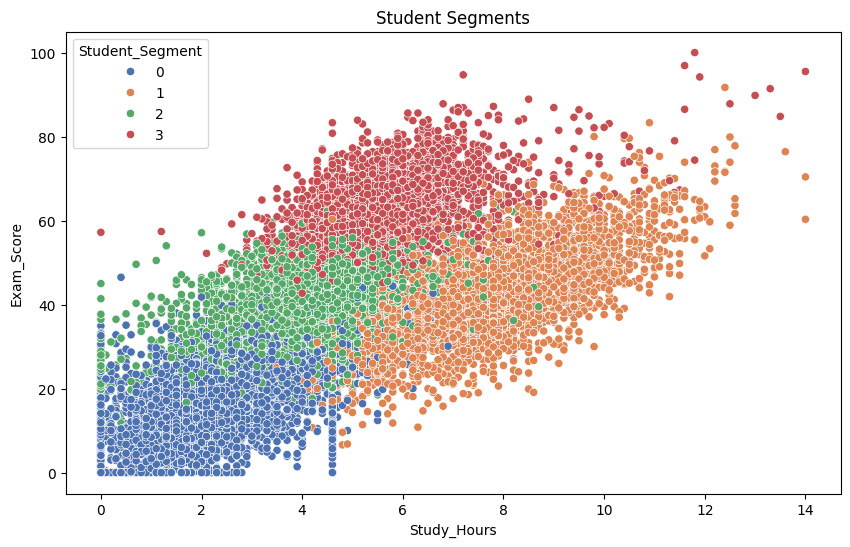

In [12]:
# ==================================================
# Cluster Visualization
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Exam_Score",
    hue="Student_Segment",
    palette="deep"
)

plt.title("Student Segments")

plt.show()

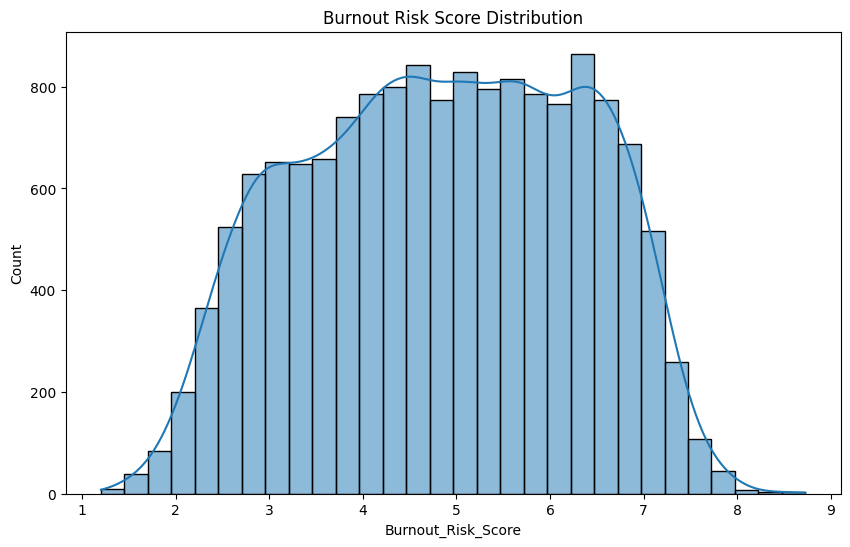

In [13]:
# ==================================================
# Burnout Risk Score Distribution
# ==================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Burnout_Risk_Score"],
    bins=30,
    kde=True
)

plt.title("Burnout Risk Score Distribution")

plt.show()

In [14]:
# ==================================================
# High Burnout Students
# ==================================================

high_risk_students = df[
    df["Burnout_Risk_Score"] > 7
]

high_risk_students.head()

,Student_ID,Date,Persona,Age,Gender,Department,Year_of_Study,Sleep_Hours,Study_Hours,Screen_Time_Hours,...,Wellness_Score,Productivity_Efficiency,Digital_Distraction_Score,Wellness_Index,Study_Consistency_Score,Sleep_Deficit,Burnout_Risk_Score,Performance_Category,High_Risk_Flag,Student_Segment
31,2,2025-01-02,Burnout,19,Male,Business,4,4.1,8.2,7.7,...,0.38,3.46,4.64,0.38,8.3,3.9,7.13,Poor,1,1
36,2,2025-01-07,Burnout,19,Male,Business,4,3.5,6.2,8.2,...,-0.16,4.26,4.82,-0.16,8.3,4.5,7.45,Poor,1,1
41,2,2025-01-12,Burnout,19,Male,Business,4,3.7,8.0,7.5,...,0.34,4.48,3.70,0.34,8.3,4.3,7.17,Poor,1,1
44,2,2025-01-15,Burnout,19,Male,Business,4,2.8,10.0,6.9,...,-0.86,2.77,3.78,-0.86,8.3,5.2,7.60,Poor,1,1
48,2,2025-01-19,Burnout,19,Male,Business,4,4.2,9.1,8.5,...,-0.27,4.04,3.73,-0.27,8.3,3.8,7.22,Average,1,1


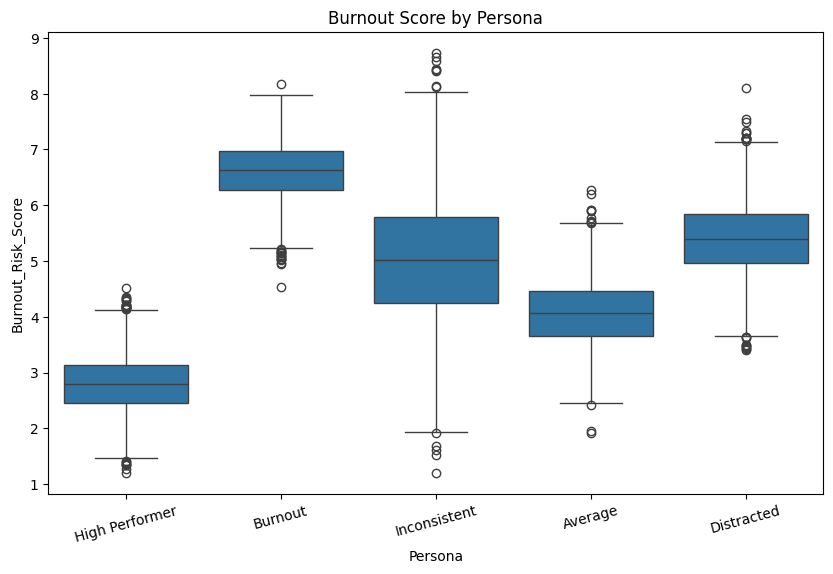

In [15]:
# ==================================================
# Persona vs Burnout
# ==================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Persona",
    y="Burnout_Risk_Score"
)

plt.title("Burnout Score by Persona")

plt.xticks(rotation=15)

plt.show()

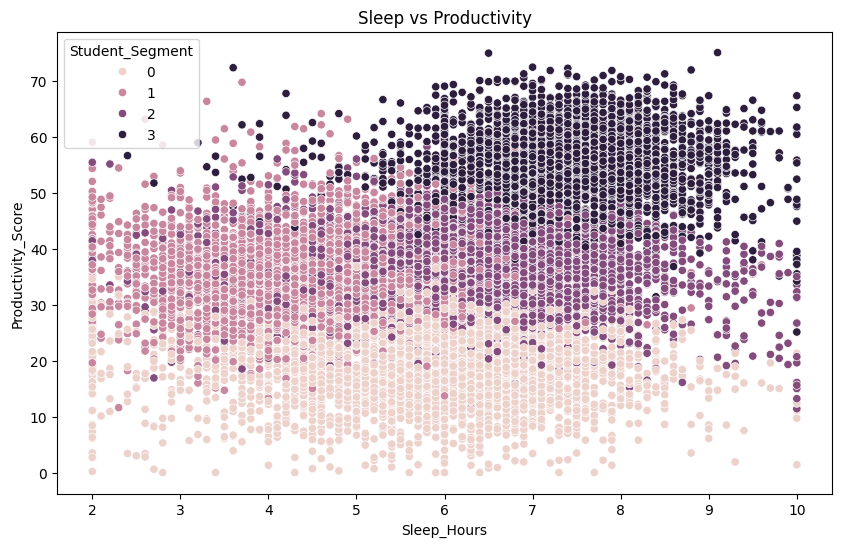

In [16]:
# ==================================================
# Productivity vs Sleep
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Productivity_Score",
    hue="Student_Segment"
)

plt.title("Sleep vs Productivity")

plt.show()

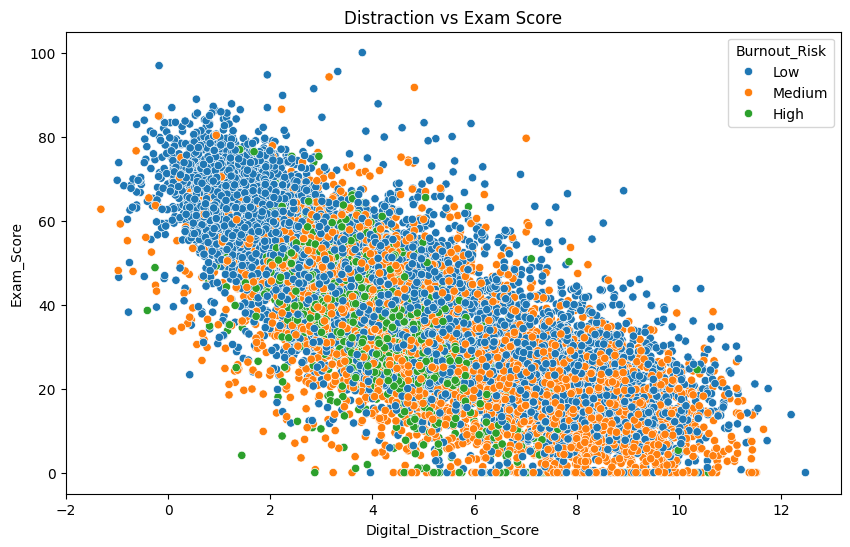

In [17]:
# ==================================================
# Digital Distraction Analysis
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Digital_Distraction_Score",
    y="Exam_Score",
    hue="Burnout_Risk"
)

plt.title("Distraction vs Exam Score")

plt.show()

In [18]:
# ==================================================
# Executive Metrics
# ==================================================

print("Average Exam Score:",
      round(df["Exam_Score"].mean(), 2))

print("Average Productivity Score:",
      round(df["Productivity_Score"].mean(), 2))

print("Average Burnout Risk Score:",
      round(df["Burnout_Risk_Score"].mean(), 2))

print("High Risk Student Count:",
      len(df[df["High_Risk_Flag"] == 1]))

Average Exam Score: 39.3
Average Productivity Score: 35.33
Average Burnout Risk Score: 4.84
High Risk Student Count: 770


In [19]:
# ==================================================
# Save Advanced Analytics Dataset
# ==================================================

advanced_dataset_path = (
    f"{PROCESSED_DATA_PATH}/"
    "student_productivity_segmented.csv"
)

df.to_csv(
    advanced_dataset_path,
    index=False
)

print("Segmented Dataset Saved!")

Segmented Dataset Saved!


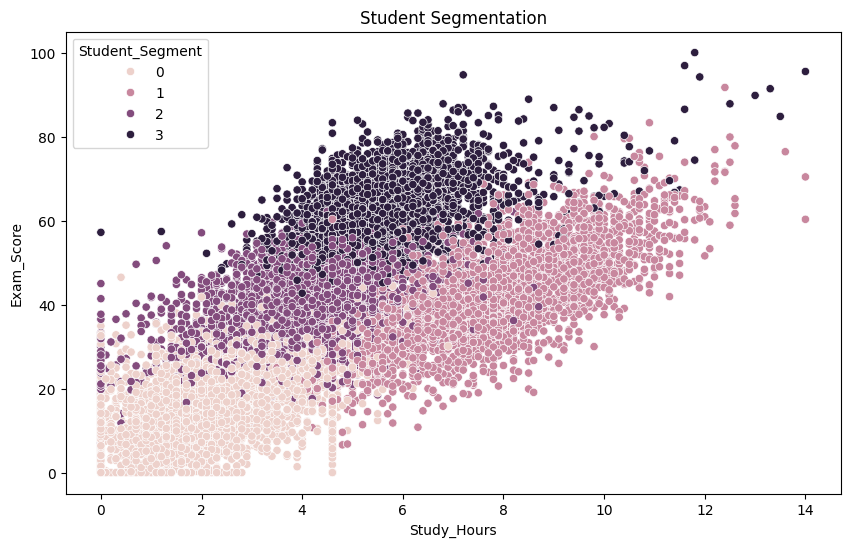

In [20]:
# ==================================================
# Save Cluster Visualization
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Exam_Score",
    hue="Student_Segment"
)

plt.title("Student Segmentation")

cluster_visual_path = (
    f"{VISUALS_PATH}/student_segments.png"
)

plt.savefig(cluster_visual_path)

plt.show()

In [22]:
# ==================================================
# Advanced Analytics Insights
# ==================================================

print("Key Advanced Insights:")

print("- Students naturally form behavioral clusters.")

print("- Burnout risk strongly correlates with low sleep.")

print("- Consistent study habits improve performance.")

print("- High screen time increases distraction risk.")

print("- Balanced wellness improves productivity.")

Key Advanced Insights:
- Students naturally form behavioral clusters.
- Burnout risk strongly correlates with low sleep.
- Consistent study habits improve performance.
- High screen time increases distraction risk.
- Balanced wellness improves productivity.
